<a href="https://colab.research.google.com/github/cvas16/Calories-Model/blob/main/Proyecto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importamos librerias:
*   **Numpy**: Realiza los cálculos numéricos de alta velocidad necesarios para procesar las matrices de datos.
*   **Pandas**: Carga y organiza los archivos de ejercicios y calorías en tablas (DataFrames) fáciles de manejar.

*   **Matplotlib y Seaborn**: Crean gráficos para identificar visualmente cómo afectan factores como el peso o la duración del ejercicio al total de calorías.

*   **Train_test_split**: Divide tus datos para que el modelo aprenda con una parte y puedas ponerlo a prueba con la otra
*   **XGBRegressor**:Es el "cerebro" matemático que analiza los patrones de los datos para aprender a predecir las calorías.


*   **Metrics** :Compara las predicciones del modelo contra los valores reales para decirte qué tan preciso es tu sistema.texto en negrita





In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Recopilación y tratamiento de datos**

In [ ]:
calorias = pd.read_csv('/content/drive/MyDrive/Proyecto-MachineLearning/Datasets/calories.csv')
calorias.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [ ]:
ejercicios_data = pd.read_csv('/content/drive/MyDrive/Proyecto-MachineLearning/Datasets/exercise.csv')
ejercicios_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


# **Combinar los dos Dataframes**

In [ ]:
calorias_data = pd.concat([ejercicios_data, calorias['Calories']], axis=1)
calorias_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [ ]:
#Combinación
calorias_data.shape

(15000, 9)

In [ ]:
#Obtener información sobre los datos
calorias_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
#Valores Nulos
calorias_data.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [ ]:
#Comprobación de valores faltantes
calorias_data.isnull().sum().sum()

np.int64(0)

# **EDA:**

# **Análisis de Datos**

In [ ]:
#Obténemos algunas medidas estadísticas sobre los datos
calorias_data.describe().T

,count,mean,std,min,25%,50%,75%,max
User_ID,15000.0,1.497736e+07,2.872851e+06,10001159.0,12474190.75,14997285.0,17449278.75,19999647.0
Age,15000.0,4.278980e+01,1.698026e+01,20.0,28.00,39.0,56.00,79.0
Height,15000.0,1.744651e+02,1.425811e+01,123.0,164.00,175.0,185.00,222.0
Weight,15000.0,7.496687e+01,1.503566e+01,36.0,63.00,74.0,87.00,132.0
Duration,15000.0,1.553060e+01,8.319203e+00,1.0,8.00,16.0,23.00,30.0
Heart_Rate,15000.0,9.551853e+01,9.583328e+00,67.0,88.00,96.0,103.00,128.0
Body_Temp,15000.0,4.002545e+01,7.792299e-01,37.1,39.60,40.2,40.60,41.5
Calories,15000.0,8.953953e+01,6.245698e+01,1.0,35.00,79.0,138.00,314.0


#**Visualización de Datos**

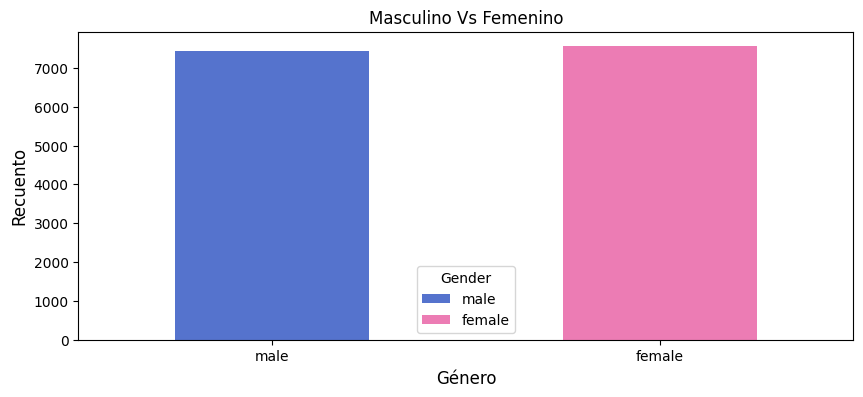

In [ ]:
colores_especificos = {"male": "royalblue", "female": "hotpink"}

#Gráfico de recuento por género
plt.figure(figsize=(10,4))

sns.countplot(x='Gender',
              data=calorias_data,
              hue="Gender",
              palette=colores_especificos,
              width=0.5,
              legend= True)

plt.title("Masculino Vs Femenino", size = 12)
plt.xlabel("Género", size = 12)
plt.ylabel("Recuento", size = 12)

#Mostramos el grafico
plt.show()

# **Valor de asimetría**

In [ ]:
columna_numerica = calorias_data.select_dtypes(include='number').columns

# Calcular y mostrar la asimetría de cada columna numérica
for columna in columna_numerica:
    # Calcular la asimetría de la columna actual
    asimetria = calorias_data[columna].skew()

    # Mostrar la asimetría de la columna actual
    print(f"La asimetría de la columna {columna}: {asimetria}")

La asimetría de la columna User_ID: 0.004788390719914252
La asimetría de la columna Age: 0.47338270096138746
La asimetría de la columna Height: -0.006189620437893538
La asimetría de la columna Weight: 0.22672530725814513
La asimetría de la columna Duration: 0.0047505366680978415
La asimetría de la columna Heart_Rate: -0.01070407972854895
La asimetría de la columna Body_Temp: -0.9943824155974582
La asimetría de la columna Calories: 0.5053713740451047


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
#Función para trazar gráficos PDF y QQ para una columna determinada
def plot_distribution(data,column_name):
    # Configurar la figura con dos subgráficos
    plt.figure(figsize=(14, 4))

    # PDF subplot
    plt.subplot(121)
    sns.distplot(data[column_name])
    plt.title(f'{column_name} PDF')

    # QQ Plot subplot
    plt.subplot(122)
    stats.probplot(data[column_name], dist="norm", plot=plt)
    plt.title(f'{column_name} QQ Plot')

    # Mostrar todos los gráficos
    plt.show()

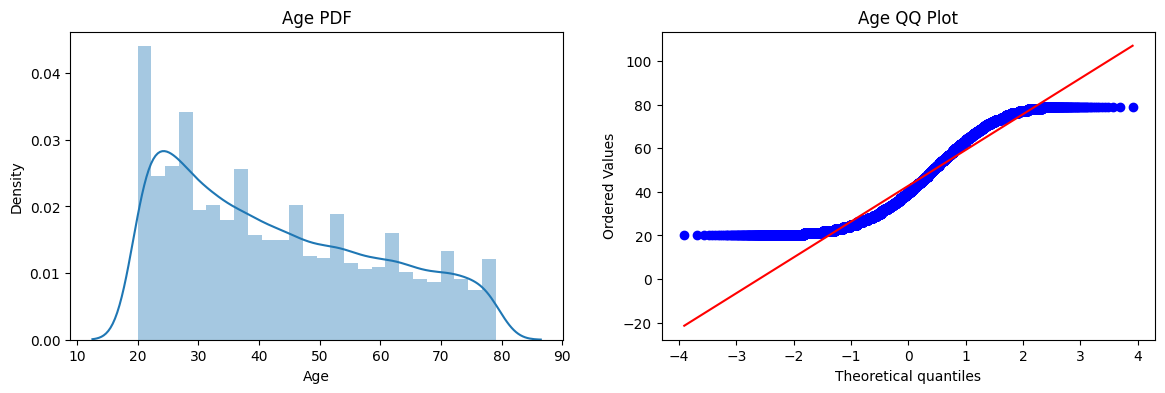

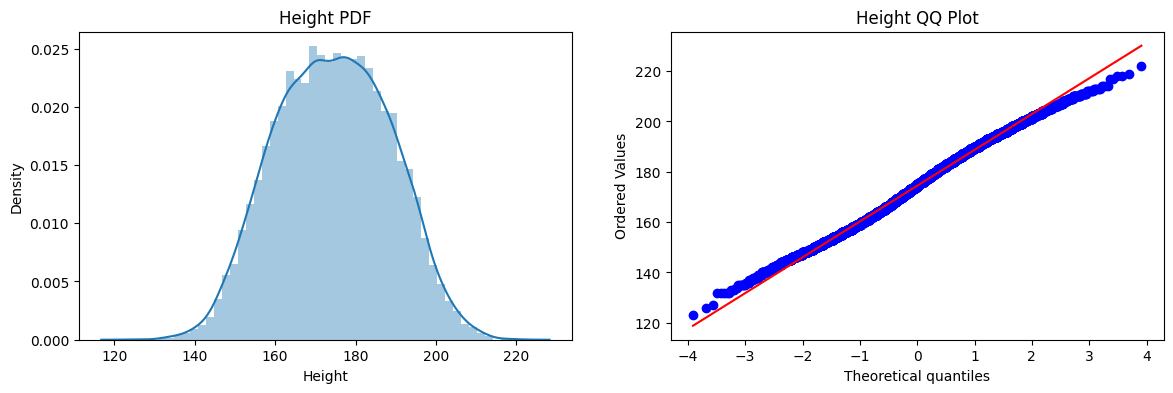

In [ ]:
# Por edad y estatura
plot_distribution(calorias_data,'Age')
plot_distribution(calorias_data,'Height')
plt.show()

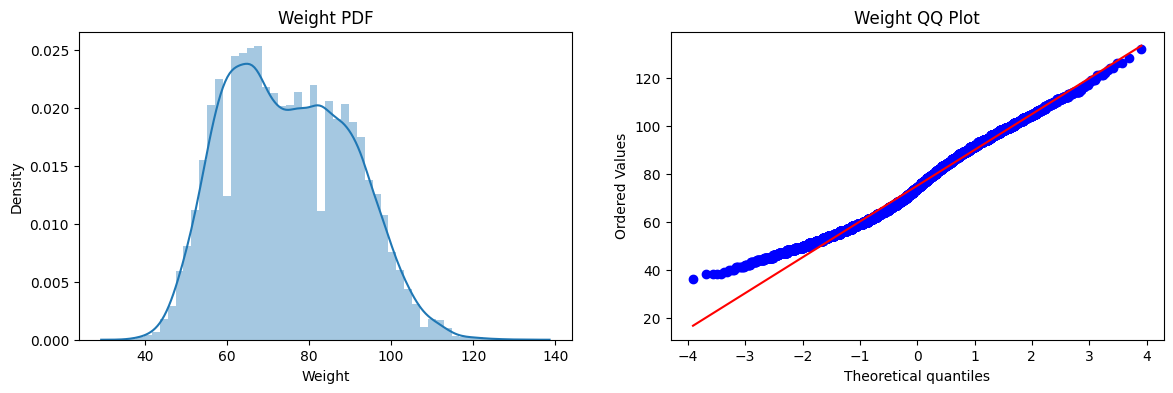

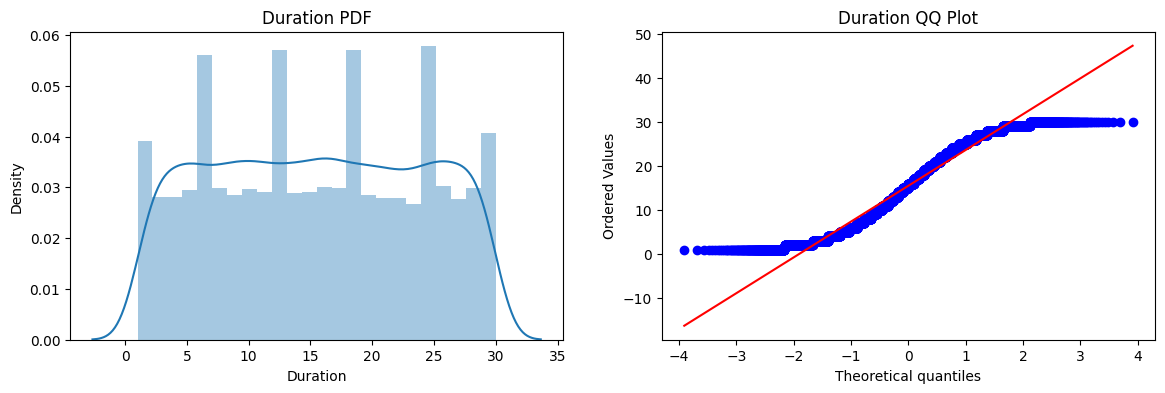

In [ ]:
# Peso y duración
plot_distribution(calorias_data,'Weight')
plot_distribution(calorias_data,'Duration')
plt.show()

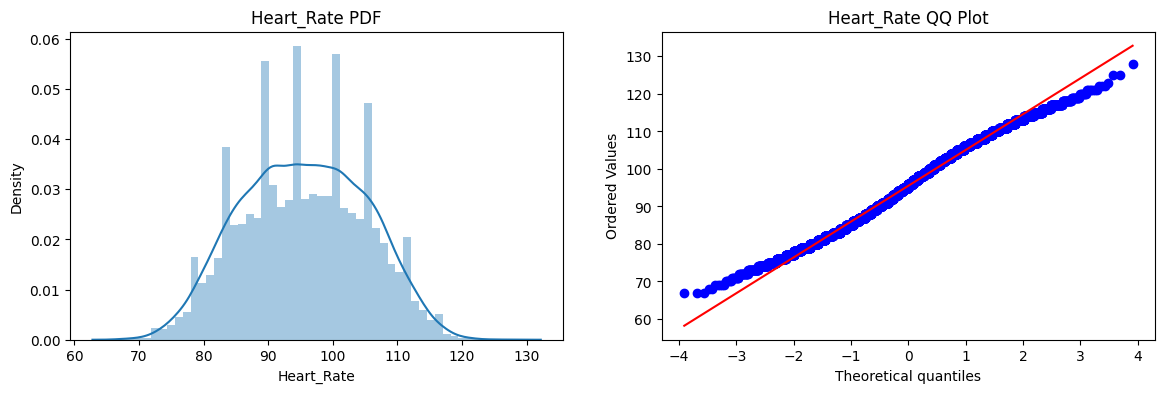

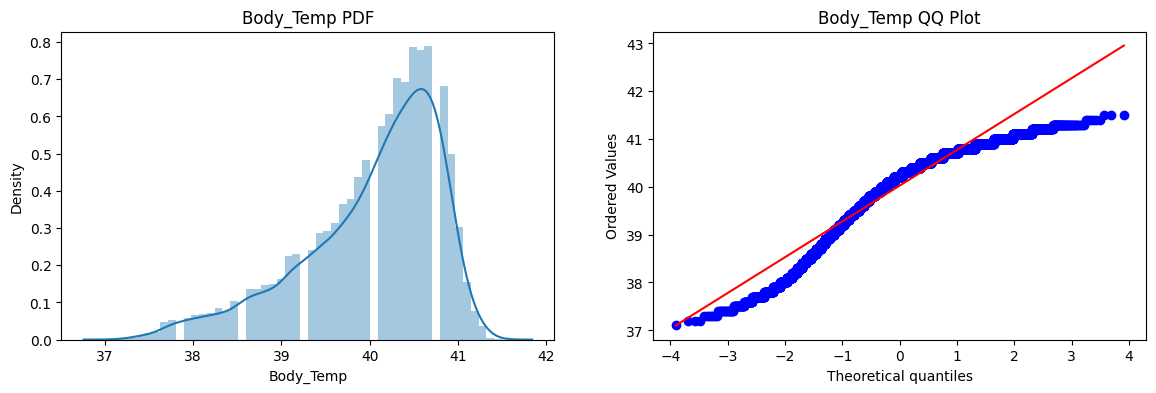

In [ ]:
#Para la frecuencia cardíaca y la temperatura corporal
plot_distribution(calorias_data,'Heart_Rate')
plot_distribution(calorias_data,'Body_Temp')
plt.show()

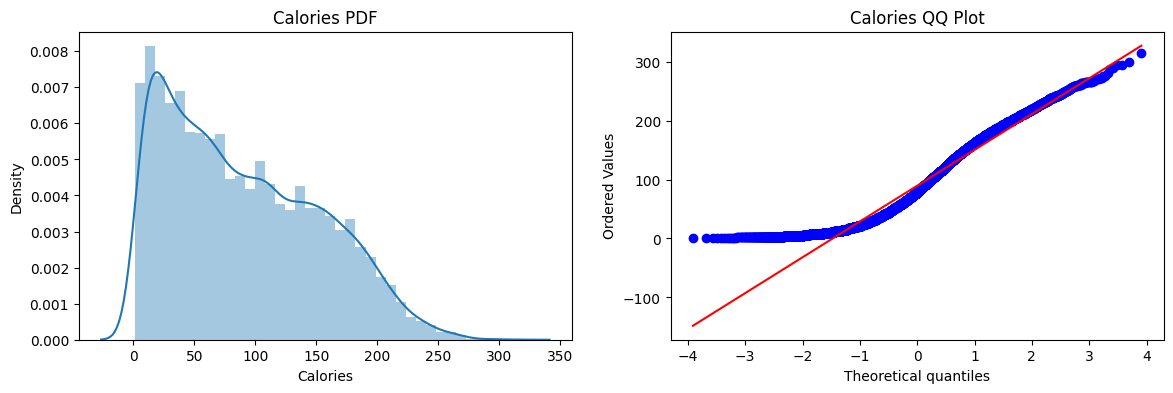

In [ ]:
#Para las calorias
plot_distribution(calorias_data,'Calories')
plt.show()

**Tras representar gráficamente todas las columnas en el PDF, podemos afirmar que las columnas "Altura", "Frecuencia cardíaca" y "Peso" siguen una distribución más o menos normal, mientras que las demás presentan una asimetría hacia la izquierda o hacia la derecha.**

# **Identificar la correlación en el conjunto de datasets**

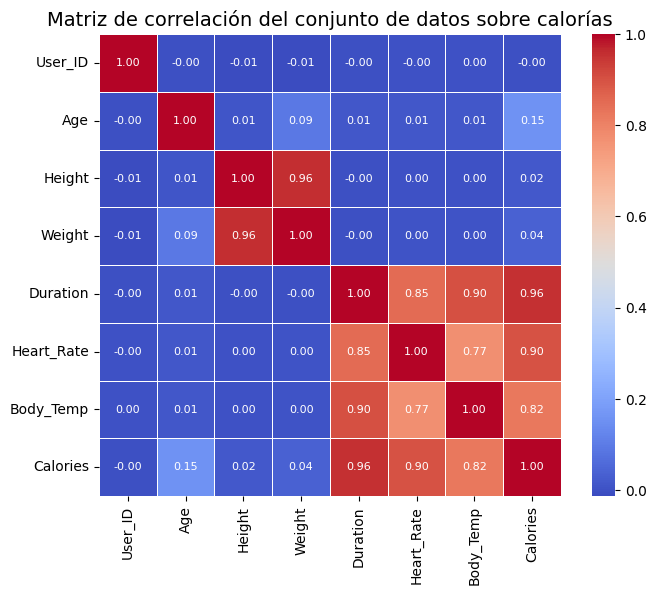

In [ ]:
# Creación de un mapa de calor para comprender la correlación

plt.figure(figsize=(8,6))
sns.heatmap(calorias_data.corr(numeric_only=True),
            cbar=True,
            square=True,
            fmt='.2f',
            annot=True,
            annot_kws={'size':8},
            linewidths=0.5,
            cmap='coolwarm')
plt.title("Matriz de correlación del conjunto de datos sobre calorías",size=14)
plt.show()

**Al trazar el mapa de calor de correlación, podemos observar que la duración, la frecuencia cardíaca y la temperatura corporal están estrechamente relacionadas con las calorías.**

# **Conversión de los datos de texto en valores numéricos**

In [ ]:
calorias_data.replace({"Gender":{'male':0,'female':1}}, inplace=True)
calorias_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


# **Eliminación de valores atípicos**

In [ ]:
import pandas as pd

def remove_outliers(df, threshold=1.5):

    # Crea una copia del DataFrame de entrada para evitar modificar el original
    df_cleaned = df.copy()

    # Recorrer las columnas
    for col in df.columns:
        # Calcular el IQR de la columna
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Definir los límites superior e inferior para los valores atípicos
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Eliminar valores atípicos
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

    return df_cleaned

# Usos
data = remove_outliers(calorias_data, threshold=1.5)
data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0


# **Definimos X e Y**

In [ ]:
X = data.drop(columns=['User_ID','Calories'], axis=1)
Y = data[['Calories']]

# **División de datos en entrenamiento y prueba**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)
len(X_train), len(Y_train), len(X_test), len(Y_test)

(11688, 11688, 2923, 2923)

# **Escalamiento de características**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplica el escalador a los datos de entrenamiento y transforma tanto los datos de entrenamiento como los de prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Entrenamiento del modelo con búsqueda aleatoria (Randomized Search CV)**

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Definimos el modelo XGBRegressor
model = XGBRegressor()

# Define la cuadrícula de parámetros para RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'booster': ['gbtree', 'gblinear', 'dart'],
    'tree_method': ['auto', 'exact', 'approx', 'hist', 'gpu_hist'],
    'n_jobs': [int(x) for x in np.linspace(1, 16, num=16)],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [0, 1, 2],
    'reg_alpha': [0, 0.1, 0.2],
    'reg_lambda': [0, 0.1, 0.2],
}

# Crea el objeto RandomizedSearchCV
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=5,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Aplica el objeto RandomizedSearchCV a los datos de entrenamiento
random_search.fit(X_train_scaled, Y_train)

# Imprimir los mejores hiperparámetros
print("Mejores los hiperparámetros:", random_search.best_params_)

# Elige el mejor modelo de la búsqueda aleatoria
best_model = random_search.best_estimator_

# Entrena el mejor modelo con todo el conjunto de entrenamiento
best_model.fit(X_train_scaled, Y_train)

Best Hyperparameters: {'tree_method': 'exact', 'subsample': 0.5, 'reg_lambda': 0, 'reg_alpha': 0.2, 'n_jobs': 5, 'n_estimators': 500, 'min_child_weight': 0, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0, 'booster': 'dart'}


XGBRegressor(base_score=None, booster='dart', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=0, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=5, num_parallel_tree=None, ...)

# **Predicción de los datos de prueba**

In [ ]:
Y_test['Pred'] = best_model.predict(X_test_scaled)

In [ ]:
Y_test

,Calories,Pred
2233,93.0,94.195908
654,48.0,47.029518
9530,199.0,198.079651
2601,143.0,143.837585
12666,52.0,53.217651
...,...,...
4226,64.0,60.684219
5242,202.0,203.148254
12558,124.0,118.389313
6790,79.0,77.681839


# **Evaluación**

In [ ]:
# Obtener el mejor modelo a partir de la búsqueda aleatoria
best_model = random_search.best_estimator_

# Entrena el mejor modelo con todo el conjunto de entrenamiento
best_model.fit(X_train_scaled, Y_train)

# Valor R al cuadrado del modelo
r_sq = best_model.score(X_train_scaled, Y_train)
print("Valor R^2 = ",r_sq)

R^2 Value =  0.999994695186615


In [ ]:
# Calcular el valor RMSE a partir de los datos de prueba (RMSE) Root <- Mean <_Square <- Error
Y_test["Sqerror"] = (Y_test["Calories"] - Y_test["Pred"]) ** 2

# Media del error cuadrático
Error_mean = Y_test["Sqerror"].mean()

import math
# RMSE(Root Mean Square Error) del modelo
RMSE = math.sqrt(Error_mean)
print("Valor RMSE = ",RMSE)

RMSE Value =  2.0708195347472604


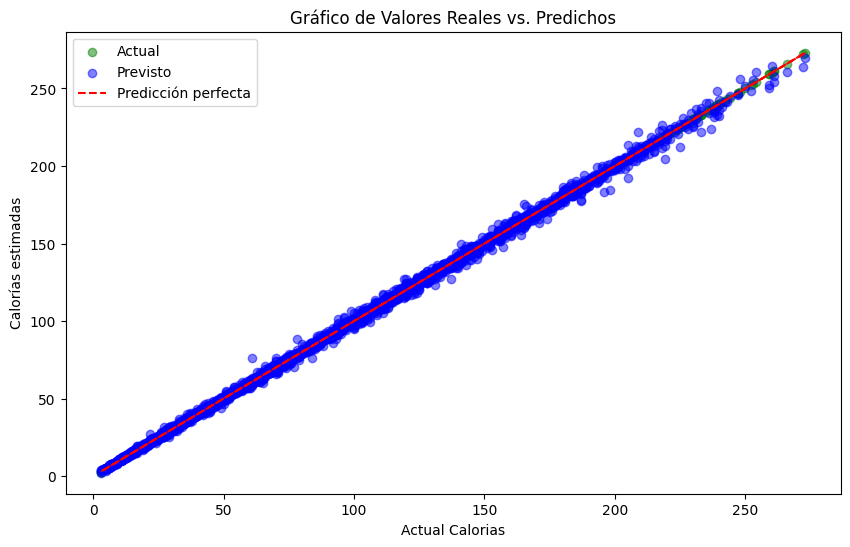

In [ ]:
# Y_test es nuestra df
df = Y_test

# Representación gráfica de los datos reales frente a los previstos con diferentes colores
plt.figure(figsize=(10, 6))

# Representar los valores reales en verde
plt.scatter(df['Calories'], df['Calories'], color='green', label='Actual', alpha=0.5)

# Representar los valores reales en azul
plt.scatter(df['Calories'], df['Pred'], color='blue', label='Previsto', alpha=0.5)

# Trazando la línea para una predicción perfecta
plt.plot(df['Calories'], df['Calories'], color='red', linestyle='--', label='Predicción perfecta')

plt.title('Gráfico de Valores Reales vs. Predichos')
plt.xlabel('Actual Calorias')
plt.ylabel('Calorías estimadas')
plt.legend()
plt.show()

# **Prueba**

In [ ]:
#Análisis de actividad del usuario
id_usuario = 14861698
detalle = data[data['User_ID'] == id_usuario].iloc[0]

print(f"ANÁLISIS DE ACTIVIDAD: USUARIO {id_usuario}")
print(f" INTENSIDAD: {detalle['Heart_Rate']} BPM.")
print(f" ESFUERZO: {detalle['Body_Temp']} °C.")
print(f" PERSISTENCIA: {detalle['Duration']} min.")
print(f" BIOMETRÍA: {detalle['Age']} años / {detalle['Weight']} kg.")
print("-" * 45)
print(f"CALORIAS QUEMADAS: {detalle['Calories']} kcal\n")

print("¿QUÉ VARIABLES INFLUYERON MÁS EN EL MODELO? ")
importances = best_model.feature_importances_
nombres_columnas = ['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

for i, nombre in enumerate(nombres_columnas):
    porcentaje = importances[i] * 100
    print(f"{nombre}: {porcentaje:.2f}% de importancia")

ANÁLISIS DE ACTIVIDAD: USUARIO 14861698
 INTENSIDAD: 94.0 BPM.
 ESFUERZO: 40.3 °C.
 PERSISTENCIA: 14.0 min.
 BIOMETRÍA: 20.0 años / 60.0 kg.
---------------------------------------------
CALORIAS QUEMADAS: 66.0 kcal

¿QUÉ VARIABLES INFLUYERON MÁS EN EL MODELO? 
Gender: 4.30% de importancia
Age: 1.73% de importancia
Height: 0.11% de importancia
Weight: 0.36% de importancia
Duration: 89.49% de importancia
Heart_Rate: 3.98% de importancia
Body_Temp: 0.04% de importancia
